# EDA – Gym Exercises Dataset

## Objectif

Vérifier que le fichier gym_exercises_dataset.csv est correctement chargé et obtenir une vue d’ensemble :

• dimensions du jeu de données (nombre de lignes et de colonnes) ;  
• typage des variables (champs textuels, listes de muscles, attributs techniques) ;  
• premières observations sur les valeurs manquantes et la présence éventuelle de doublons ;  
• cohérence générale du corpus avant analyse statistique et préparation NLP.


## Interprétation attendue

À partir de cette première inspection, il s’agira de commenter :

• la taille globale du dataset (nombre de lignes / colonnes) ;  
• la nature des variables (descriptifs textuels, attributs biomécaniques, catégories d’équipements) ;  
• la présence éventuelle de valeurs manquantes ou de champs textuels incomplets ;  
• l’existence (ou non) de doublons dans les données brutes ;  
• la cohérence générale des premières lignes (valeurs lisibles, descriptions complètes, muscles cohérents).

Cette interprétation sert de point de départ pour juger de la qualité du corpus et préparer les étapes suivantes : nettoyage, normalisation textuelle et structuration pour le traitement NLP du projet TrAIn.me.

## Configuration notebook

### Importation des librairies essentielles

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import prince

from pathlib import Path
import sys

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

# === Localiser automatiquement le package 'themes' en remontant l'arborescence ===
root = Path.cwd()  # ex : .../train.me/src/notebooks/eda/health_fitness_dataset
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
        "Vérifie l'arborescence : il doit exister un dossier 'themes/' quelque part au-dessus."
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("✅ Ajouté au PYTHONPATH :", themes_root)
print("📂 Contenu de", themes_root, ":", [x.name for x in themes_root.iterdir()])

from themes.theme_train_me import set_trainme_theme

c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Ajouté au PYTHONPATH : c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks
📂 Contenu de c:\Users\fback\Desktop\Projets\Dev\GitHub\train.me\src\notebooks : ['eda', 'model_training', 'preprocessing', 'themes', '__init__.py']


#### Configuration d’affichage et thème TrAIn.me


In [3]:
# Options d’affichage pour les tableaux
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# =============================
# Thème TrAIn.me (Seaborn/Matplotlib)
# =============================
USE_DARK_THEME = True  # bascule possible vers un thème clair si besoin

palette_trainme = set_trainme_theme(
    context="talk",
    font_scale=1.05,
    use_dark=USE_DARK_THEME
)

palette_trainme


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

### Activation du thème TrAIn.me

In [4]:
if USE_DARK_THEME:
    palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
else:
    sns.set_style("ticks")              # style clair sobre, axes renforcés
    sns.set_context("talk", font_scale=1.05)
    palette_trainme = sns.color_palette("deep")  # palette par défaut sobre
    print("🎨 Style activé : 'ticks' → sobre, axes renforcés (présentation pro)")

# Exemple de vérification :
print("Palette active :", palette_trainme.as_hex() if hasattr(palette_trainme, "as_hex") else palette_trainme)


Palette active : ['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']


## Chargement et inspection initiale

Cette section vise à charger le fichier gym_exercises_dataset.csv, vérifier ses dimensions
et obtenir un premier aperçu des données brutes. Elle reprend la même démarche que pour
les autres EDA du projet : contrôle du chargement, visualisation des premières lignes,
statistiques descriptives de base, analyse des valeurs manquantes et des doublons, puis
liste complète des colonnes disponibles.


#### Chargement du dataset gym_exercises_dataset.csv


In [5]:
# Téléchargement du dataset depuis Kaggle
dataset_path = kagglehub.dataset_download("prajwaldongre/best-50-exercise-for-your-body")

# Recherche du fichier CSV dans le dossier téléchargé
csv_files = [f for f in os.listdir(dataset_path) if f.endswith(".csv")]
print("Fichiers trouvés :", csv_files)

# Construction du chemin complet vers le CSV
file_path = os.path.join(dataset_path, csv_files[0])


# Lecture du fichier CSV
df = pd.read_csv(file_path)

# Informations de confirmation
print("Dataset chargé avec succès !")
print(f"Dimensions : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")


100%|██████████| 1.76k/1.76k [00:00<00:00, 1.80MB/s]

Extracting files...
Fichiers trouvés : ['Top 50 Excerice for your body.csv']
Dataset chargé avec succès !
Dimensions : 50 lignes et 8 colonnes



#### Aperçu des premières lignes


In [6]:
df.head(10)


,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level
0,Push-ups,3,15,Builds upper body strength,200,"Chest, Triceps, Shoulders",NaN,Intermediate
1,Squats,4,12,Strengthens lower body,223,"Quadriceps, Hamstrings, Glutes",NaN,Beginner
2,Lunges,3,10,Improves balance and coordination,275,"Quadriceps, Hamstrings, Glutes",NaN,Beginner
3,Burpees,3,10,Full body workout,355,Full Body,NaN,Advanced
4,Mountain Climbers,3,20,Improves cardiovascular fitness,240,"Core, Shoulders, Legs",NaN,Intermediate
5,Jumping Jacks,3,30,Improves coordination and cardiovascular health,295,Full Body,NaN,Beginner
6,Bicycle Crunches,3,20,Targets abdominal muscles,210,Core,NaN,Intermediate
7,Dips,3,12,Strengthens triceps and chest,180,"Triceps, Chest",Parallel Bars or Chair,Intermediate
8,Pull-ups,3,8,Builds upper body strength,250,"Back, Biceps",Pull-up Bar,Advanced
9,Russian Twists,3,20,Improves core rotation strength,190,"Core, Obliques",None or Dumbbell,Intermediate


#### Informations sur le typage, les valeurs manquantes et les doublons


In [7]:
# Typage et complétude globale
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Name of Exercise             50 non-null     object
 1   Sets                         50 non-null     int64 
 2   Reps                         50 non-null     int64 
 3   Benefit                      50 non-null     object
 4   Burns Calories (per 30 min)  50 non-null     int64 
 5   Target Muscle Group          50 non-null     object
 6   Equipment Needed             30 non-null     object
 7   Difficulty Level             50 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.3+ KB


### Statistiques descriptives des variables numériques

In [8]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Sets,50.0,3.12,0.328261,3.0,3.0,3.0,3.00,4.0
Reps,50.0,12.78,4.559314,5.0,10.0,12.0,15.00,30.0
Burns Calories (per 30 min),50.0,229.96,58.896991,130.0,180.0,221.5,278.75,355.0


### Analyse des valeurs manquantes et doublons

In [9]:
# Comptage des valeurs manquantes par colonne
missing_counts = df.isna().sum().sort_values(ascending=False)

print("\n🔎 Valeurs manquantes par colonne (top 20) :")
display(missing_counts.head(20))

# Comptage des doublons ligne à ligne
n_duplicates = df.duplicated().sum()
print(f"\n🧬 Nombre de doublons (lignes strictement identiques) : {n_duplicates}")


🔎 Valeurs manquantes par colonne (top 20) :


Equipment Needed               20
Name of Exercise                0
Sets                            0
Reps                            0
Benefit                         0
Burns Calories (per 30 min)     0
Target Muscle Group             0
Difficulty Level                0
dtype: int64


🧬 Nombre de doublons (lignes strictement identiques) : 0


#### Liste complète des colonnes disponibles


In [10]:
print("\n--- Liste des colonnes du dataset ---")
print(df.columns.tolist())



--- Liste des colonnes du dataset ---
['Name of Exercise', 'Sets', 'Reps', 'Benefit', 'Burns Calories (per 30 min)', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level']


## Statistiques descriptives et distribution des variables

Cette section analyse la distribution des variables numériques du dataset, identifie les
ordres de grandeur, met en évidence les valeurs extrêmes éventuelles et prépare les
étapes suivantes de détection d’outliers et de corrélation.


#### Objectif

- Résumer la distribution des variables numériques (moyenne, médiane, étendue).
- Observer la dispersion et la variabilité des mesures.
- Identifier d'éventuelles valeurs extrêmes ou atypiques.
- Préparer la détection d’outliers (boxplots, IQR).


#### Interprétation attendue

À l’issue de cette section, l’analyse devra mettre en évidence :

- les valeurs centrales des variables clés (nombre de séries, nombre de répétitions, calories brûlées) pour caractériser l’intensité moyenne des exercices ;
- la dispersion et la variabilité des mesures (écarts-types, min/max, quartiles), permettant d’identifier des exercices plus « légers » ou nettement plus exigeants ;
- la présence éventuelle de valeurs extrêmes ou atypiques (par exemple nombre de répétitions très élevé ou dépense calorique particulièrement importante) qui pourront faire l’objet d’un traitement spécifique ;
- les premiers ordres de grandeur utiles pour le projet TrAIn.me (plages typiques de volume d’entraînement et de dépense énergétique), en vue de préparer la recommandation d’exercices adaptés au profil de l’utilisateur.


#### Statistiques descriptives globales


In [12]:
# --- Colonnes numériques du dataset ---
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Variables numériques détectées ({len(num_cols)}) : {num_cols}")

# Statistiques descriptives de base
stats_num = df[num_cols].describe().T
display(stats_num)

# Quelques repères métier
if "Sets" in df.columns:
    print(f"\nNombre moyen de séries : {df['Sets'].mean():.2f}")

if "Reps" in df.columns:
    print(f"Nombre moyen de répétitions : {df['Reps'].mean():.2f}")

if "Burns Calories (per 30 min)" in df.columns:
    print(f"Calories moyennes brûlées en 30 min : {df['Burns Calories (per 30 min)'].mean():.0f} kcal")


Variables numériques détectées (3) : ['Sets', 'Reps', 'Burns Calories (per 30 min)']


,count,mean,std,min,25%,50%,75%,max
Sets,50.0,3.12,0.328261,3.0,3.0,3.0,3.00,4.0
Reps,50.0,12.78,4.559314,5.0,10.0,12.0,15.00,30.0
Burns Calories (per 30 min),50.0,229.96,58.896991,130.0,180.0,221.5,278.75,355.0



Nombre moyen de séries : 3.12
Nombre moyen de répétitions : 12.78
Calories moyennes brûlées en 30 min : 230 kcal


#### Distribution des variables clés


Variables représentées : ['Sets', 'Reps', 'Burns Calories (per 30 min)']


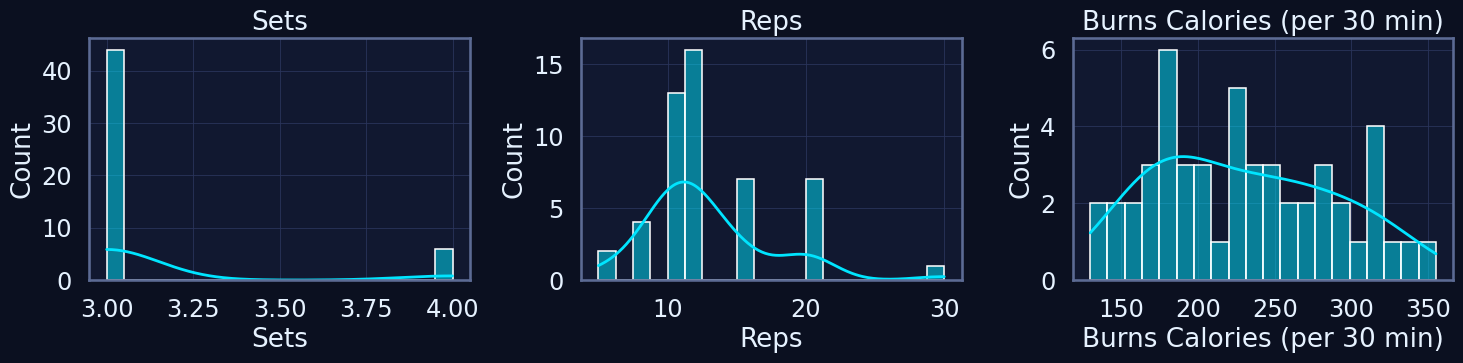

In [13]:
# Sélection des variables numériques réellement pertinentes
num_vars = num_cols  # toutes les variables numériques sont métier ici
print(f"Variables représentées : {num_vars}")

n = len(num_vars)
n_cols = 3
n_rows = int(np.ceil(n / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(num_vars, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(col)
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Boxplots pour repérer les outliers


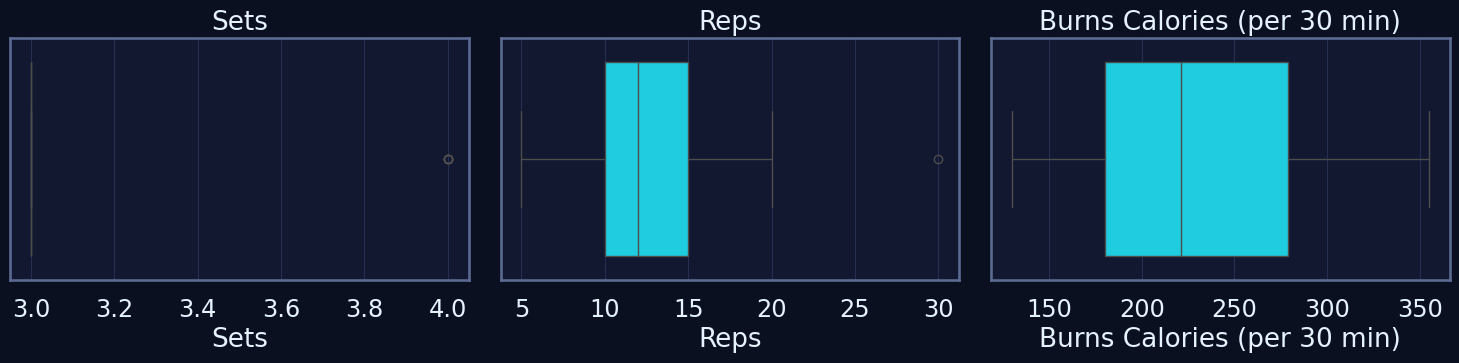

In [14]:
plt.figure(figsize=(5 * len(num_vars), 4))

for i, col in enumerate(num_vars, 1):
    plt.subplot(1, len(num_vars), i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.grid(True, axis="x")

plt.tight_layout()
plt.show()


#### Statistiques descriptives enrichies


In [15]:
if num_cols:
    desc = df[num_cols].describe().T
    desc["missing_%"] = df[num_cols].isna().mean() * 100
    desc["zeros_%"] = (df[num_cols] == 0).mean() * 100
    desc["skew"] = df[num_cols].skew()
    desc["kurt"] = df[num_cols].kurt()

    display(desc.sort_values("std", ascending=False))
else:
    print("ℹ️ Aucune variable numérique disponible pour des statistiques enrichies.")


,count,mean,std,min,25%,50%,75%,max,missing_%,zeros_%,skew,kurt
Burns Calories (per 30 min),50.0,229.96,58.896991,130.0,180.0,221.5,278.75,355.0,0.0,0.0,0.274614,-0.949834
Reps,50.0,12.78,4.559314,5.0,10.0,12.0,15.00,30.0,0.0,0.0,1.379863,3.070059
Sets,50.0,3.12,0.328261,3.0,3.0,3.0,3.00,4.0,0.0,0.0,2.411701,3.973747


#### Détection rapide d’outliers (IQR)


In [16]:
iqr_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    iqr_report[col] = len(outliers)

iqr_df = pd.DataFrame.from_dict(iqr_report, orient="index", columns=["outliers"])

iqr_df.sort_values("outliers", ascending=False)


,outliers
Sets,6
Reps,1
Burns Calories (per 30 min),0


#### Aperçu corrélations (sous-ensemble lisible)


C:\Users\fback\AppData\Local\Temp\ipykernel_40392\4255799464.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


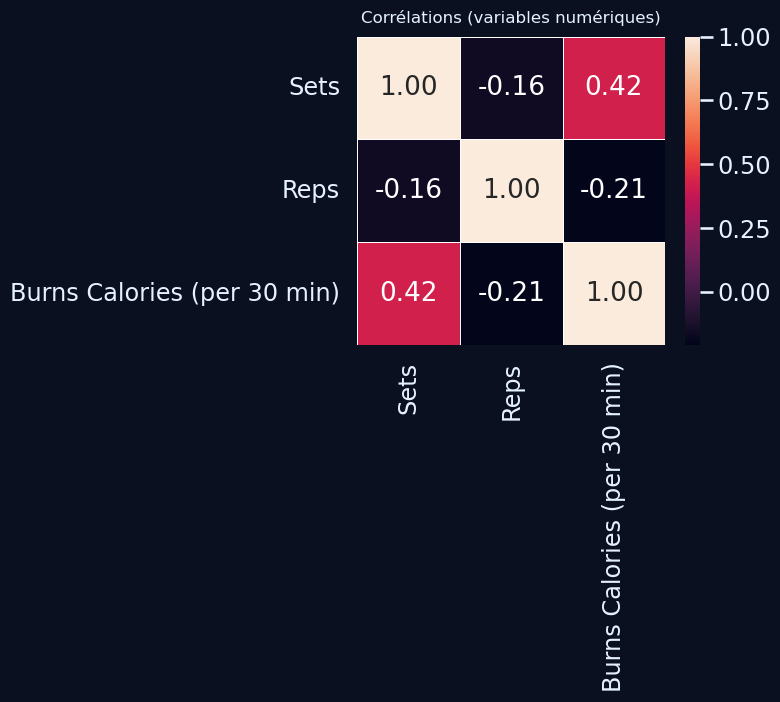

In [17]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        square=True,
        cbar=True,
        linewidths=0.5,
    )
    plt.title("Corrélations (variables numériques)", fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Corrélation non pertinente : une seule variable numérique disponible.")


## Visualisation univariée

Cette section complète les statistiques descriptives par une analyse visuelle des distributions
des variables numériques. L’objectif est de vérifier la forme des distributions (symétrie,
concentration, valeurs extrêmes) pour les principales mesures d’intensité des exercices.


#### Objectif

- Visualiser la répartition des variables numériques (Sets, Reps, Burns Calories).
- Identifier les niveaux les plus fréquents et les éventuels déséquilibres.
- Repérer visuellement des valeurs extrêmes ou atypiques.
- Préparer les décisions de nettoyage ou de regroupement pour la suite de l’analyse.


#### Interprétation attendue

À l’issue de cette section, l’analyse devra :

- décrire la forme des distributions (exercices plutôt modérés ou fortement concentrés
  autour de certaines valeurs de séries, de répétitions ou de calories brûlées) ;
- signaler la présence éventuelle de niveaux très peu représentés ou de valeurs extrêmes ;
- confirmer les ordres de grandeur observés (volume d’entraînement et dépense énergétique
  typiques) ;
- fournir des éléments visuels pour classer les exercices selon leur intensité globale,
  en préparation des futures étapes de recommandation.


#### Sélection robuste des variables numériques à visualiser


In [19]:
# --- Sélection des variables numériques pertinentes pour la visualisation univariée ---

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print("Variables numériques détectées :", num_cols)

# Dans ce dataset, toutes les variables numériques sont métier (volume & intensité)
vars_univariate = num_cols.copy()

print("Variables retenues pour la visualisation univariée :", vars_univariate)


Variables numériques détectées : ['Sets', 'Reps', 'Burns Calories (per 30 min)']
Variables retenues pour la visualisation univariée : ['Sets', 'Reps', 'Burns Calories (per 30 min)']


#### Visualisation des distributions univariées (hist + KDE)


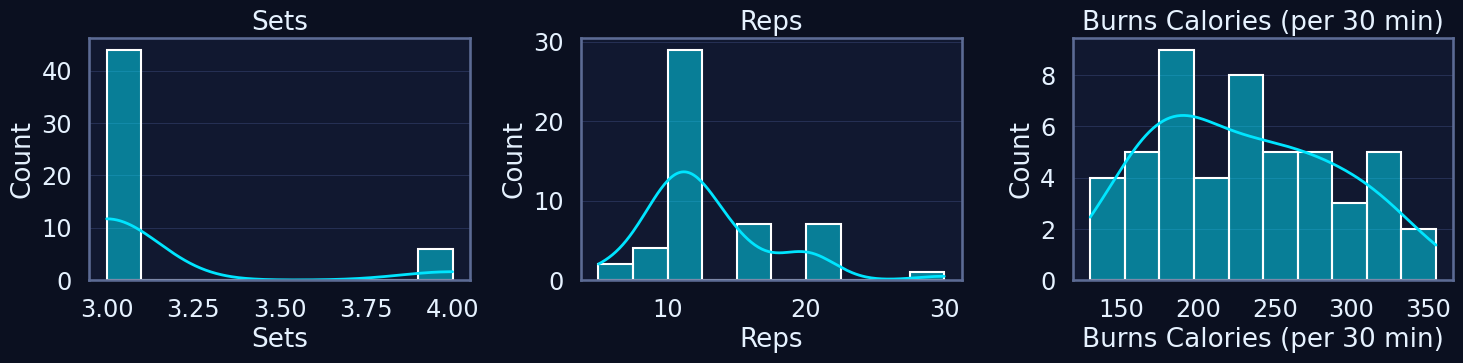

In [20]:
if not vars_univariate:
    print("ℹ️ Aucune variable numérique pertinente à visualiser.")
else:
    n = len(vars_univariate)
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], bins=10, kde=True)
        plt.title(col)
        plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()


#### Boxplots univariés pour détection visuelle d’outliers


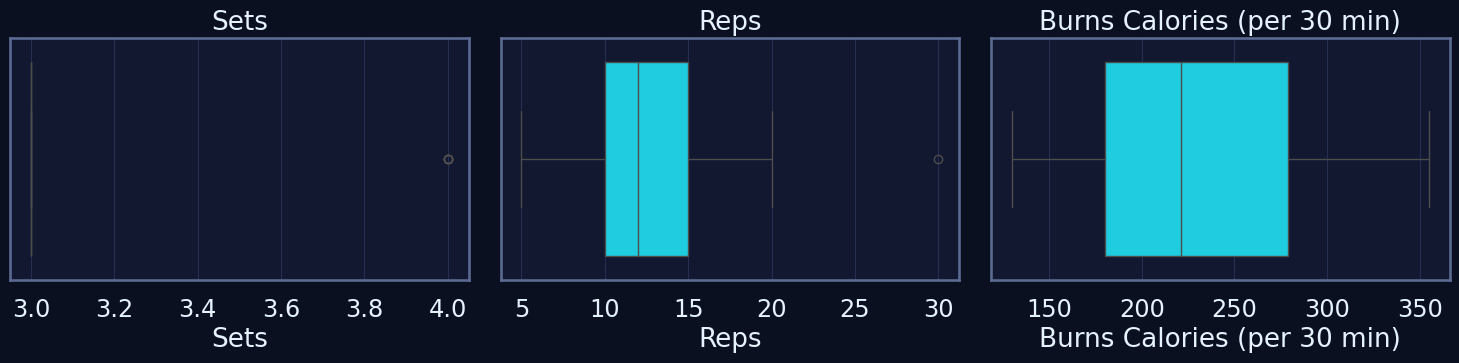

In [21]:
if not vars_univariate:
    print("ℹ️ Aucun boxplot pertinent à afficher (pas de variable numérique métier).")
else:
    plt.figure(figsize=(5 * len(vars_univariate), 4))

    for i, col in enumerate(vars_univariate, start=1):
        plt.subplot(1, len(vars_univariate), i)
        sns.boxplot(x=df[col])
        plt.title(col)
        plt.grid(True, axis="x")

    plt.tight_layout()
    plt.show()


## Visualisation bivariée

Cette section explore les relations entre variables numériques et catégorielles,
afin d’identifier des tendances d’intensité selon les groupes musculaires,
le niveau de difficulté ou la présence d’équipement.


#### Objectif

- Examiner comment les variables numériques varient selon les catégories (difficulty level, equipment, groupes musculaires).
- Détecter d’éventuels patterns (ex. exercices avancés brûlant plus de calories).
- Repérer les co-occurrences entre catégories pour mieux structurer le référentiel.
- Préparer la construction de règles métier pour TrAIn.me.


#### Interprétation attendue

L’analyse devra permettre :

- d’identifier les catégories associées à des intensités plus fortes (reps, calories) ;
- de vérifier si le niveau de difficulté suit une progression logique ;
- de faire ressortir des regroupements naturels entre groupes musculaires, difficulté et volume d’effort ;
- de repérer les catégories rares ou atypiques (par exemple exercices avancés mais peu gourmands en calories).


#### Relations catégorielles ↔ numériques (Difficulty Level)


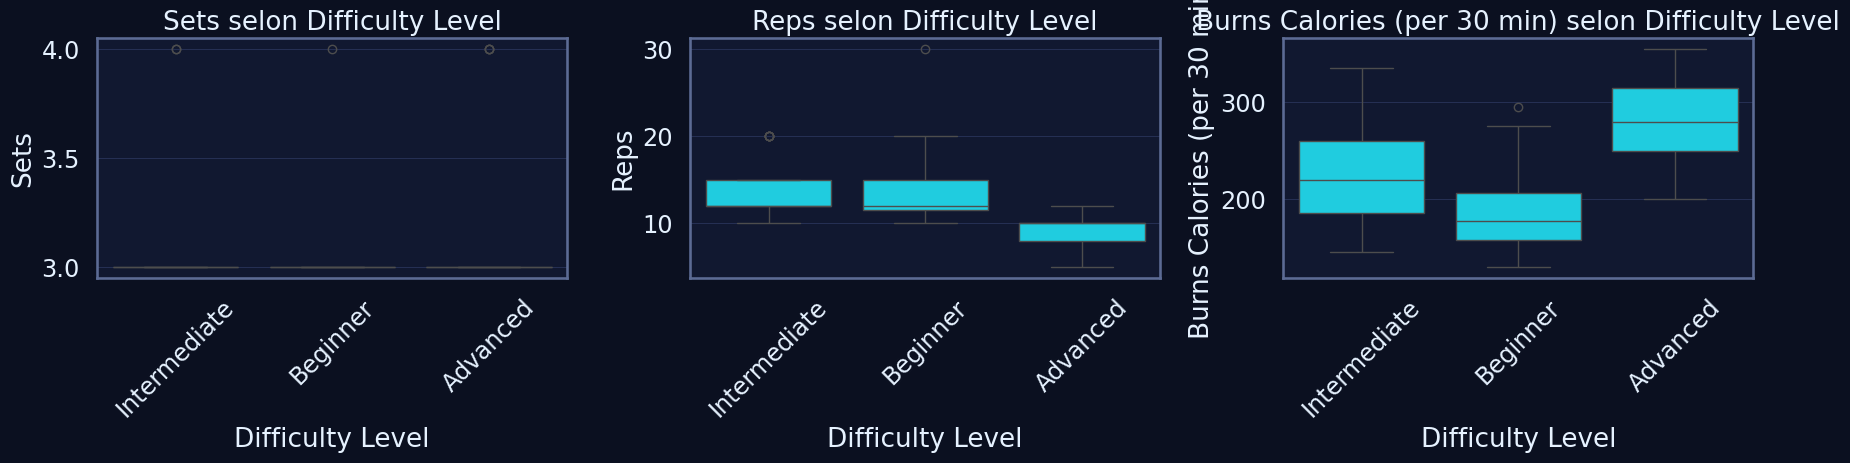

In [22]:
# Variables numériques
num_cols = df.select_dtypes(include="number").columns.tolist()

plt.figure(figsize=(6 * len(num_cols), 5))
for i, col in enumerate(num_cols, start=1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(data=df, x="Difficulty Level", y=col)
    plt.title(f"{col} selon Difficulty Level")
    plt.xticks(rotation=45)
    plt.grid(True, axis="y")

plt.tight_layout()
plt.show()


#### Co-occurrences entre catégories (crosstab + heatmap)

Cette analyse met en évidence les combinaisons les plus fréquentes entre
« Target Muscle Group » et « Difficulty Level » pour repérer les zones
d’effort typiques (ex. exercices avancés orientés full-body).


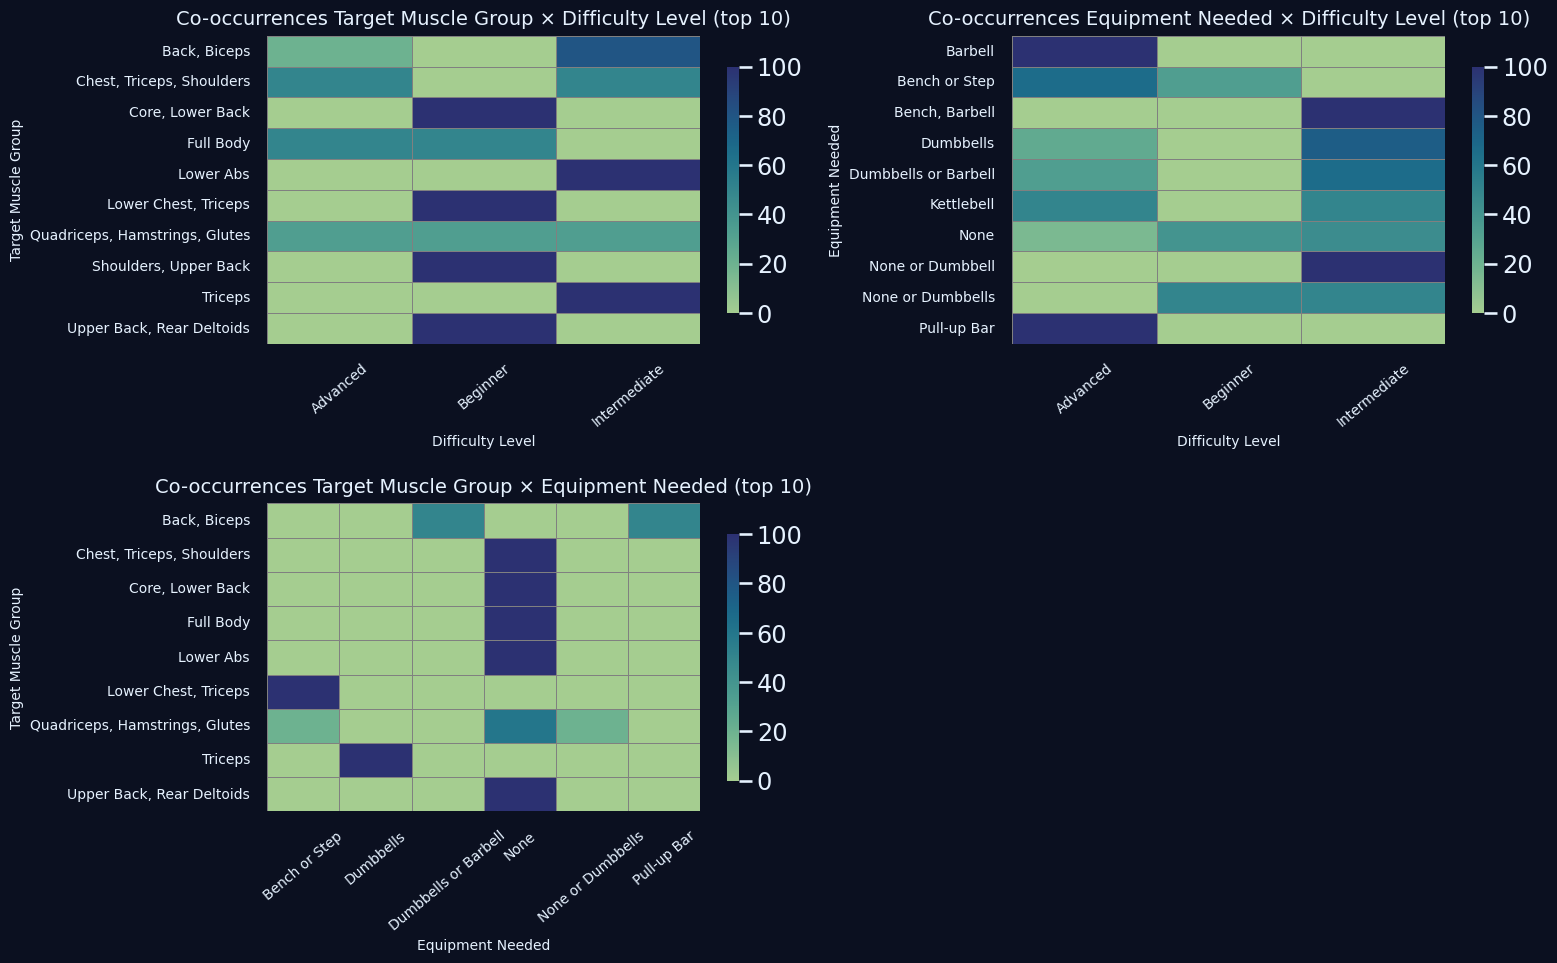

In [24]:
# ============================================================
# Préparation des catégories (Top 50 Exercises for Your Body)
# ============================================================

df_cat = df.copy()
# On remplace les NaN d'équipement par "None" pour garder l'info "sans matériel"
if "Equipment Needed" in df_cat.columns:
    df_cat["Equipment Needed"] = df_cat["Equipment Needed"].fillna("None")


def plot_crosstab_heatmaps(
    df,
    pairs,
    top_k=12,
    normalize=None,     # None | "row" | "col"  (pourcentages)
    annotate=False,     # True pour afficher les valeurs
    log_color=False,    # True pour mieux voir les faibles valeurs
    figsize=(16, 9),
    title_fontsize=13,
    tick_fontsize=9,
    label_rotation_x=30,
    label_rotation_y=0,
    cbar_shrink=0.85,
):
    """Heatmaps propres et lisibles pour analyser les co-occurrences de catégories."""
    if not pairs:
        print("ℹ️ Aucune paire de catégories disponible.")
        return

    n = len(pairs)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for i, (a, b) in enumerate(pairs):
        ax = axes[i]

        # Top-k pour réduire la cardinalité (plus lisible)
        a_top = df[a].value_counts().index[:top_k]
        b_top = df[b].value_counts().index[:top_k]
        sub = df[df[a].isin(a_top) & df[b].isin(b_top)]

        ct = pd.crosstab(sub[a], sub[b])

        # Normalisation optionnelle en pourcentages
        if normalize in {"row", "col"}:
            axis = 1 if normalize == "row" else 0
            ct = (
                ct.div(
                    ct.sum(axis=axis).replace(0, np.nan),
                    axis=1 - axis,
                ) * 100
            ).round(1)

        # Palette & échelle adaptées
        heatmap_kwargs = dict(
            cmap="crest",
            linewidths=0.4,
            linecolor="grey",
            cbar_kws={"shrink": cbar_shrink},
            square=False,
        )
        if log_color and normalize is None:
            # Log uniquement pour les comptes bruts (pas en %)
            vmin = max(ct.replace(0, np.nan).min().min(), 1e-6)
            vmax = ct.max().max()
            heatmap_kwargs["norm"] = LogNorm(vmin=vmin, vmax=vmax)

        # Annotations optionnelles
        if annotate:
            sns.heatmap(
                ct,
                ax=ax,
                **heatmap_kwargs,
                annot=True,
                fmt=".1f" if normalize else "g",
                annot_kws={"fontsize": max(tick_fontsize - 1, 7)},
            )
        else:
            sns.heatmap(ct, ax=ax, **heatmap_kwargs)

        ax.set_title(
            f"Co-occurrences {a} × {b} (top {top_k})",
            fontsize=title_fontsize,
            pad=8,
        )
        ax.set_xlabel(b, fontsize=10)
        ax.set_ylabel(a, fontsize=10)

        # Ticks propres
        ax.tick_params(axis="x", labelsize=tick_fontsize, rotation=label_rotation_x)
        ax.tick_params(axis="y", labelsize=tick_fontsize, rotation=label_rotation_y)
        ax.grid(False)

    # Masquer axes vides si nombre impair
    for j in range(i + 1, nrows * ncols):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# ============================================================
# Sélection des paires & appel (version Top 50 Exercises)
# ============================================================
pairs = []
if {"Target Muscle Group", "Difficulty Level"}.issubset(df_cat.columns):
    pairs.append(("Target Muscle Group", "Difficulty Level"))
if {"Equipment Needed", "Difficulty Level"}.issubset(df_cat.columns):
    pairs.append(("Equipment Needed", "Difficulty Level"))
if {"Target Muscle Group", "Equipment Needed"}.issubset(df_cat.columns):
    pairs.append(("Target Muscle Group", "Equipment Needed"))

# 👉 Paramètres recommandés pour ce dataset :
# - normalize="row" pour lire des ratios par catégorie de ligne
# - annotate=False pour éviter la surcharge visuelle
# - log_color=False car on travaille en %
plot_crosstab_heatmaps(
    df_cat,
    pairs=pairs,
    top_k=10,
    normalize="row",     # None = comptes bruts ; "row"/"col" = pourcentages
    annotate=False,
    log_color=False,
    figsize=(16, 10),
    title_fontsize=14,
    tick_fontsize=10,
    label_rotation_x=40,
    label_rotation_y=0,
    cbar_shrink=0.8,
)


#### Comptage empilé (stacked) : Equipment Needed × Difficulty Level


Difficulty Level,Advanced,Beginner,Intermediate
Equipment Needed,,,
Bench or Step,2,1,0
Dumbbells,1,0,3
Dumbbells or Barbell,1,0,2
Kettlebell,1,0,1
None,3,8,9
None or Dumbbells,0,1,1


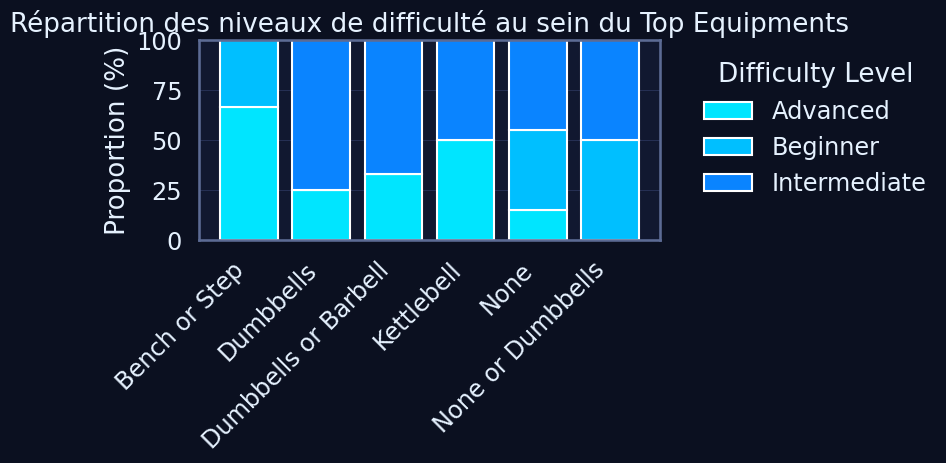

In [25]:
# On travaille avec une copie où les NaN d'équipement sont remplacés par "None"
df_stack = df.copy()
df_stack["Equipment Needed"] = df_stack["Equipment Needed"].fillna("None")

# On retient les équipements les plus fréquents
top_equip_for_stack = df_stack["Equipment Needed"].value_counts().head(6).index
stack_subset = df_stack[df_stack["Equipment Needed"].isin(top_equip_for_stack)].copy()

# Crosstab : Equipment Needed × Difficulty Level
crosstab_diff = pd.crosstab(
    stack_subset["Equipment Needed"],
    stack_subset["Difficulty Level"]
)
display(crosstab_diff)

# Normalisation en pourcentage pour lecture plus intuitive
crosstab_diff_pct = crosstab_diff.div(crosstab_diff.sum(axis=1), axis=0) * 100

plt.figure(figsize=(9, 5))

bottom = np.zeros(len(crosstab_diff_pct))
x = np.arange(len(crosstab_diff_pct.index))

for diff in crosstab_diff_pct.columns:
    values = crosstab_diff_pct[diff].values
    plt.bar(
        x,
        values,
        bottom=bottom,
        label=diff,
    )
    bottom += values

plt.xticks(x, crosstab_diff_pct.index, rotation=45, ha="right")
plt.ylabel("Proportion (%)")
plt.title("Répartition des niveaux de difficulté au sein du Top Equipments")
plt.legend(title="Difficulty Level", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Analyse multivariée (PCA - MCA – FAMD simplifiée)

### Objectif

Explorer la structure globale du Top 50 des exercices en combinant plusieurs approches
multivariées :

- **PCA** : résumer l’information portée par les variables numériques (nombre de séries,
  répétitions, calories brûlées) et identifier les axes principaux d’intensité/volume.
- **MCA** : analyser les relations entre les modalités catégorielles (groupe musculaire,
  équipement, difficulté, bénéfice principal) et repérer les familles d’exercices similaires.
- **FAMD** : obtenir une vision intégrée des données mixtes (numériques + catégorielles)
  pour visualiser comment se structurent les exercices dans un espace factoriel commun.

Ces analyses servent à mieux comprendre la logique interne du Top 50 et à préparer la
construction de futures features de recommandation pour TrAIn.me (clusters d’exercices,
profils de difficulté, familles par muscles et équipements).


### Interprétation attendue

- La **PCA** devrait faire apparaître :
  - un premier axe lié au **volume de travail** (combinaison de Sets, Reps et calories
    brûlées) ;
  - un second axe différenciant plutôt les exercices **très coûteux en énergie** de ceux
    plus légers à volume comparable.

- La **MCA** est attendue pour mettre en évidence :
  - des regroupements entre certains **groupes musculaires** et **équipements**
    (par ex. jambes ↔ machines, poitrine/épaules ↔ barres/haltères) ;
  - une séparation claire entre exercices **débutant**, **intermédiaire** et **avancé**.

- La **FAMD** doit fournir une carte globale où :
  - les exercices difficiles et très dépensiers se regroupent dans une zone spécifique ;
  - les exercices sans matériel et orientés “full body” ou “core” se distinguent des mouvements
    localisés et très équipés.

Ces résultats guideront la création de profils d’exercices (faciles, coûteux, ciblés, full body)
et alimenteront les futurs modèles de recommandation / NLP de TrAIn.me.


### PCA (Principal Component Analysis)

On applique une PCA sur les variables numériques :

- `Sets`
- `Reps`
- `Burns Calories (per 30 min)`

L’objectif est de :
- mesurer la **variance expliquée** par les deux premières composantes ;
- projeter les exercices dans le plan (PC1, PC2) pour repérer les profils proches ;
- identifier quelles variables contribuent le plus à ces axes (loadings).


#### Sélection & scaling des variables numériques

In [28]:
# Sélection des variables numériques
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Variables retenues pour la PCA ({len(num_pca_cols)}) :")
print(num_pca_cols)

# DataFrame numérique pour la PCA (on sécurise avec dropna par précaution)
X_num = df[num_pca_cols].dropna().copy()

# Standardisation des variables (centrage-réduction)
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_num)

print("✅ Données numériques standardisées pour la PCA.")

Variables retenues pour la PCA (3) :
['Sets', 'Reps', 'Burns Calories (per 30 min)']
✅ Données numériques standardisées pour la PCA.


#### PCA globale + variance expliquée

In [29]:
# On limite le nombre de composantes pour la lisibilité (ex. 6 premières)
n_components = min(6, X_scaled.shape[1])
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

explained_var = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(n_components)],
    "Explained_Variance_Ratio": pca.explained_variance_ratio_,
    "Cumulative_Variance": pca.explained_variance_ratio_.cumsum(),
})

display(explained_var)


,PC,Explained_Variance_Ratio,Cumulative_Variance
0,PC1,0.51479,0.51479
1,PC2,0.29314,0.80793
2,PC3,0.19207,1.00000


#### Visualisation PCA 2D


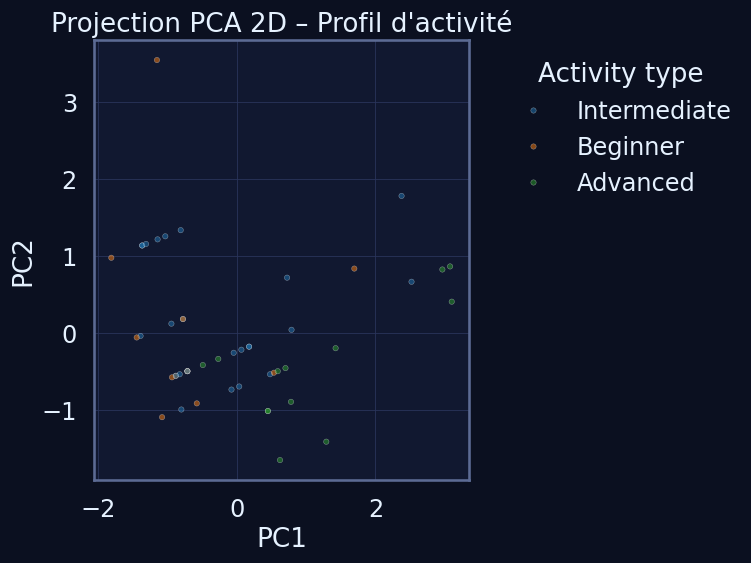

In [32]:
# PCA en 2 composantes pour visualisation
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"],
    index=X_num.index  # pour recoller avec df
)

# On ajoute une variable catégorielle pour la coloration (ex. Difficulty Level)
if "Difficulty Level" in df.columns:
    df_pca["Difficulty Level"] = df.loc[df_pca.index, "Difficulty Level"]
else:
    df_pca["Difficulty Level"] = "Unknown"

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca.sample(min(5000, len(df_pca))),  # échantillon pour garder une figure lisible
    x="PC1",
    y="PC2",
    hue="Difficulty Level",
    alpha=0.5,
    s=15,
    palette="tab10"
)
plt.title("Projection PCA 2D – Profil d'activité")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Activity type")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Identification des variables les plus contributrices

In [33]:
# Matrice des contributions (loadings) pour PC1 et PC2
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=num_pca_cols
)

# On ajoute une colonne avec la contribution totale (norme L2 des 2 loadings)
loadings["Contribution_abs"] = (loadings["PC1_loading"]**2 + loadings["PC2_loading"]**2) ** 0.5

# Tri des variables les plus contributrices
top_loadings = loadings.sort_values("Contribution_abs", ascending=False).head(15)
display(top_loadings.round(4))


,PC1_loading,PC2_loading,Contribution_abs
Reps,-0.4311,0.8969,0.9951
Sets,0.6271,0.3767,0.7316
Burns Calories (per 30 min),0.6488,0.2317,0.6889


### MCA (Multiple Correspondence Analysis)

La MCA est appliquée sur les variables catégorielles clés :

- `Benefit`
- `Target Muscle Group`
- `Equipment Needed`
- `Difficulty Level`

Elle permet de visualiser :
- les **familles d’exercices** partageant les mêmes groupes musculaires et équipements ;
- la proximité entre certains niveaux de difficulté et certains types de mouvements.


#### Encodage + sélection

In [38]:
# Sélection des colonnes catégorielles
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Variables catégorielles :", cat_cols)

# One-hot encoding complet
df_cat = df[cat_cols].dropna().astype(str).copy()

print("Variables catégorielles utilisées pour la MCA :", cat_cols)
print("Shape après sélection :", df_cat.shape)


Variables catégorielles : ['Name of Exercise', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level']
Variables catégorielles utilisées pour la MCA : ['Name of Exercise', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level']
Shape après sélection : (30, 5)


#### Exécution de la MCA

Nous utilisons un algorithme de MCA pour obtenir des axes factoriels 
qui synthétisent les relations entre modalités qualitatives.


In [39]:
mca = prince.MCA(
    n_components=2,
    n_iter=5,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42,
)

mca_fit = mca.fit(df_cat)
mca_components = mca_fit.transform(df_cat)

mca_components.columns = ["Dim1", "Dim2"]

display(mca_components.head())

,Dim1,Dim2
7,-0.548622,-1.388112
8,-0.262090,0.729470
9,-0.409916,-1.439688
11,0.085647,1.922956
12,-0.822188,-0.746897


#### Visualisation MCA 2D

Cette projection 2D permet d’identifier des regroupements entre profils utilisateurs
en fonction de leurs caractéristiques qualitatives (type d’activité, intensité, état de santé…).


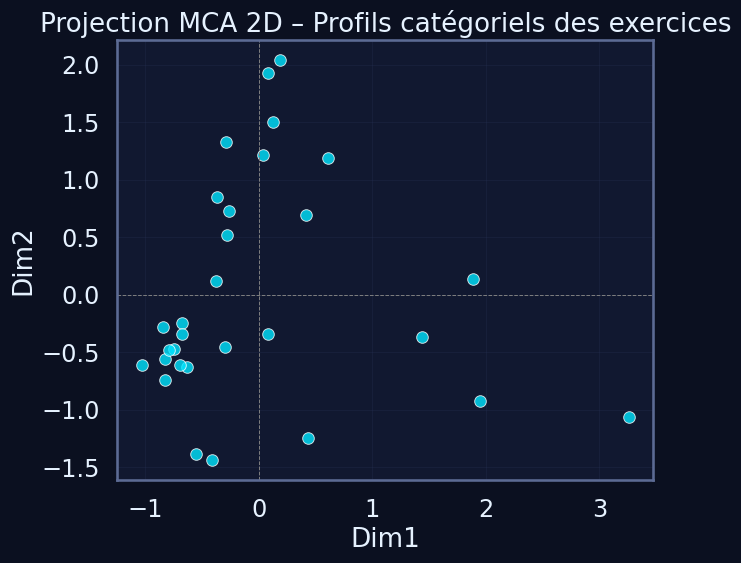

Coordonnées des modalités (aperçu) :


,0,1
Name of Exercise__Bench Press,-0.850599,-0.779609
Name of Exercise__Box Jumps,0.193617,2.128295
Name of Exercise__Bulgarian Split Squats,0.436231,0.724283
Name of Exercise__Calf Raises,1.488816,-0.383304
Name of Exercise__Deadlifts,0.088606,2.007175
Name of Exercise__Decline Push-ups,0.635860,1.238009
Name of Exercise__Dips,-0.567579,-1.448906
Name of Exercise__Dragon Flags,0.134295,1.565492
Name of Exercise__Face Pulls,0.447812,-1.306606
Name of Exercise__Incline Push-ups,1.952762,0.145314


In [40]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=mca_components["Dim1"],
    y=mca_components["Dim2"],
    alpha=0.8,
    s=70,
)

plt.axhline(0, color="grey", linestyle="--", linewidth=0.7)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.7)
plt.title("Projection MCA 2D – Profils catégoriels des exercices")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optionnel : coordonnées des modalités (pour inspection rapide)
modality_coords = mca_fit.column_coordinates(df_cat)
print("Coordonnées des modalités (aperçu) :")
display(modality_coords.head(15))

#### Modalités les plus contributrices

Cette étape met en évidence les modalités catégorielles les plus déterminantes dans la variabilité globale.


In [41]:
# Contributions des modalités (colonnes) aux premières dimensions

mca_contrib = mca_fit.column_contributions_  # DataFrame (modalités x composantes)
display(mca_contrib.head())

# Option : focus sur les modalités les plus contributrices sur les deux 1ères composantes
if mca_contrib.shape[1] >= 2:
    mca_contrib["Contribution_PC1_PC2"] = (
        mca_contrib.iloc[:, 0].abs() + mca_contrib.iloc[:, 1].abs()
    )
    top_modalities = mca_contrib.sort_values(
        "Contribution_PC1_PC2", ascending=False
    ).head(20)

    print("Top 20 modalités les plus contributrices (PC1 + PC2) :")
    display(top_modalities)
else:
    print("Contributions par modalité :")
    display(mca_contrib.sort_values(mca_contrib.columns[0], ascending=False).head(20))


,0,1
Name of Exercise__Bench Press,0.005173,0.003927
Name of Exercise__Box Jumps,0.000336,0.033031
Name of Exercise__Bulgarian Split Squats,0.001455,0.003662
Name of Exercise__Calf Raises,0.013030,0.000654
Name of Exercise__Deadlifts,0.000064,0.028866


Top 20 modalités les plus contributrices (PC1 + PC2) :


,0,1,Contribution_PC1_PC2
Difficulty Level__Beginner,0.135804,0.008660,0.144464
Difficulty Level__Advanced,0.000092,0.111174,0.111266
Name of Exercise__Wall Angels,0.082254,0.009433,0.091687
Equipment Needed__Wall,0.082254,0.009433,0.091687
Benefit__Improves shoulder mobility and posture,0.082254,0.009433,0.091687
"Target Muscle Group__Shoulders, Upper Back",0.082254,0.009433,0.091687
Difficulty Level__Intermediate,0.036803,0.047119,0.083921
Benefit__Improves shoulder health and posture,0.021921,0.019435,0.041356
Name of Exercise__Resistance Band Pull-Aparts,0.028693,0.006047,0.034740
"Target Muscle Group__Upper Back, Rear Deltoids",0.028693,0.006047,0.034740


### FAMD (Factor Analysis of Mixed Data)

La FAMD combine les variables numériques et catégorielles dans une même analyse
factorielle. Elle est particulièrement adaptée ici, car notre Top 50 mélange :

- des indicateurs **quantitatifs** (Sets, Reps, Calories) ;
- des attributs **qualitatifs** (groupe musculaire, équipement, difficulté, bénéfice).

L’objectif est d’obtenir une **carte synthétique** où chaque exercice est positionné en
fonction de l’ensemble de ses caractéristiques.


#### Préparation des données pour la FAMD

Nous sélectionnons les variables numériques et catégorielles pertinentes, excluons les
identifiants techniques, gérons les valeurs manquantes et, si nécessaire, échantillonnons
le dataset pour garantir des temps de calcul raisonnables.


In [57]:
# Colonnes numériques / catégorielles pour la FAMD
num_cols_famd = [
    c for c in ["Sets", "Reps", "Burns Calories (per 30 min)"] if c in df.columns
]
cat_cols_famd = [
    c
    for c in [
        "Benefit",
        "Target Muscle Group",
        "Equipment Needed",
        "Difficulty Level",
    ]
    if c in df.columns
]

mixed_cols = num_cols_famd + cat_cols_famd

df_mixed = df[mixed_cols].dropna().copy()

# ✅ Très important : float pour les numériques, str pour les catégorielles
df_mixed[num_cols_famd] = df_mixed[num_cols_famd].astype(float)
df_mixed[cat_cols_famd] = df_mixed[cat_cols_famd].astype(str)

print("Colonnes utilisées pour la FAMD :", mixed_cols)
print("Types :")
print(df_mixed.dtypes)

Colonnes utilisées pour la FAMD : ['Sets', 'Reps', 'Burns Calories (per 30 min)', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level']
Types :
Sets                           float64
Reps                           float64
Burns Calories (per 30 min)    float64
Benefit                         object
Target Muscle Group             object
Equipment Needed                object
Difficulty Level                object
dtype: object


#### FAMD : inertie expliquée

Nous appliquons la FAMD sur le jeu de données mixte (numérique + catégoriel) afin de
quantifier la part de variabilité capturée par les premières dimensions.


In [63]:
# Colonnes numériques / catégorielles pour la FAMD
num_cols_famd = [
    c for c in ["Sets", "Reps", "Burns Calories (per 30 min)"] if c in df.columns
]
cat_cols_famd = [
    c
    for c in [
        "Benefit",
        "Target Muscle Group",
        "Equipment Needed",
        "Difficulty Level",
    ]
    if c in df.columns
]

mixed_cols = num_cols_famd + cat_cols_famd

# On NE droppe que sur les numériques, et on remplit les catégorielles
df_mixed = df[mixed_cols].copy()

# Numériques → float
df_mixed[num_cols_famd] = df_mixed[num_cols_famd].astype(float)

# Catégorielles → str + remplissage des NaN
for c in cat_cols_famd:
    df_mixed[c] = df_mixed[c].fillna("None").astype(str)

# Si vraiment tu veux sécuriser : drop seulement si un numérique manque
df_mixed = df_mixed.dropna(subset=num_cols_famd)

print("Shape df_mixed :", df_mixed.shape)

# ========================= FAMD =========================
famd = prince.FAMD(
    n_components=2,
    n_iter=5,
    copy=True,
    check_input=True,
    engine="sklearn",
    random_state=42,
)

famd_fit = famd.fit(df_mixed)
coords = famd_fit.transform(df_mixed)

famd_components = pd.DataFrame(
    coords,
    columns=["Dim1", "Dim2"],
    index=df_mixed.index,
)

# Ajout du niveau de difficulté pour la couleur
if "Difficulty Level" in df_mixed.columns:
    famd_components["Difficulty Level"] = df_mixed["Difficulty Level"].values
else:
    famd_components["Difficulty Level"] = "Unknown"

print(famd_components.head())


# Inertie expliquée par dimension (via eigenvalues_)
eigenvalues = famd_fit.eigenvalues_

print("Eigenvalues / Inertie FAMD :")
display(eigenvalues)

# Conversion en vecteur numpy (quelle que soit la forme renvoyée)
vals = np.array(eigenvalues, dtype=float).ravel()

# Normalisation pour obtenir la part d'inertie expliquée par dimension
explained = vals / vals.sum()

famd_inertia_df = pd.DataFrame({
    "Dim": [f"Dim{i+1}" for i in range(len(explained))],
    "Explained_Inertia": explained,
    "Cumulative_Inertia": explained.cumsum()
})

print("\nInertie expliquée par dimension (FAMD) :")
display(famd_inertia_df)

Shape df_mixed : (50, 7)
   Dim1  Dim2 Difficulty Level
0   NaN   NaN     Intermediate
1   NaN   NaN         Beginner
2   NaN   NaN         Beginner
3   NaN   NaN         Advanced
4   NaN   NaN     Intermediate
Eigenvalues / Inertie FAMD :


array([7.81479227, 6.8222647 ])


Inertie expliquée par dimension (FAMD) :


,Dim,Explained_Inertia,Cumulative_Inertia
0,Dim1,0.533905,0.533905
1,Dim2,0.466095,1.000000


#### Visualisation FAMD 2D

La projection sur les deux premières dimensions permet d’observer la structure globale
des profils utilisateurs, en particulier en fonction du type d’activité.


In [65]:
# plt.figure(figsize=(7, 6))
# sns.scatterplot(
#     data=famd_components,
#     x="Dim1",
#     y="Dim2",
#     hue="Difficulty Level",
#     palette="viridis",
#     s=70,
#     alpha=0.85,
# )

# plt.axhline(0, color="grey", linestyle="--", linewidth=0.7)
# plt.axvline(0, color="grey", linestyle="--", linewidth=0.7)
# plt.title("FAMD – Carte globale des exercices (mixte : volume × catégories)")
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
# plt.show()


#### Variables et modalités les plus contributrices

Nous identifions ici les variables (et leurs modalités) contribuant le plus aux deux
premières dimensions de la FAMD, afin de mieux comprendre les axes principaux en termes métier.


In [62]:
# Contributions des colonnes (variables/modalités) aux dimensions
col_contrib = famd_fit.column_contributions_

display(col_contrib.head())

# Score de contribution combinée sur les deux premières dimensions
if col_contrib.shape[1] >= 2:
    col_contrib["Contribution_Dim1_Dim2"] = (
        col_contrib.iloc[:, 0].abs() + col_contrib.iloc[:, 1].abs()
    )

    top_contrib = col_contrib.sort_values(
        "Contribution_Dim1_Dim2", ascending=False
    ).head(25)

    print("Top 25 variables/modalités les plus contributrices (Dim1 + Dim2) :")
    display(top_contrib)
else:
    print("Contributions disponibles (une seule dimension) :")
    display(col_contrib.sort_values(col_contrib.columns[0], ascending=False).head(25))


component,0,1
variable,,
Sets,0.046850,0.003510
Reps,0.051925,0.002098
Burns Calories (per 30 min),0.080010,0.000602
Benefit,0.115765,0.130946
Difficulty Level,0.081351,0.113836


Top 25 variables/modalités les plus contributrices (Dim1 + Dim2) :


component,0,1,Contribution_Dim1_Dim2
variable,,,
Benefit,0.115765,0.130946,0.246711
Target Muscle Group,0.113902,0.129460,0.243362
Equipment Needed,0.099754,0.122764,0.222518
Difficulty Level,0.081351,0.113836,0.195187
Burns Calories (per 30 min),0.080010,0.000602,0.080612
Reps,0.051925,0.002098,0.054023
Sets,0.046850,0.003510,0.050360


## Détection d’anomalies et valeurs extrêmes

Cette section vise à identifier d’éventuelles valeurs aberrantes dans les variables numériques
(Sets, Reps, Calories brûlées), à repérer les modalités catégorielles rares et à vérifier la
présence d'exercices atypiques dans l’espace multivarié (MCA).


### Objectif

- Détecter les valeurs extrêmes parmi les variables numériques du dataset.
- Vérifier la cohérence statistique globale des 50 exercices.
- Repérer des modalités catégorielles très rares (équipement, groupe musculaire).
- Identifier des observations atypiques via l’espace factoriel MCA.


### Interprétation attendue

L'analyse doit permettre :

- de confirmer si certains exercices se démarquent fortement par leur volume
  (sets/reps) ou leur dépense énergétique ;
- d’identifier si ces écarts relèvent d'une logique métier (exercices dynamiques,
  full-body, explosifs) ou d’une anomalie réelle ;
- de détecter les modalités très peu représentées, susceptibles de créer du bruit
  dans l’analyse ou la recommandation ;
- de repérer, via la MCA, des exercices isolés dans l’espace des modalités,
  indiquant une signature inhabituelle ou atypique.


### Imports & sélection des colonnes pertinentes


In [66]:
# Colonnes numériques
num_cols = ["Sets", "Reps", "Burns Calories (per 30 min)"]
num_cols = [c for c in num_cols if c in df.columns]

# Colonnes catégorielles
cat_cols = [
    "Benefit",
    "Target Muscle Group",
    "Equipment Needed",
    "Difficulty Level",
]
cat_cols = [c for c in cat_cols if c in df.columns]

print("Variables numériques :", num_cols)
print("Variables catégorielles :", cat_cols)


Variables numériques : ['Sets', 'Reps', 'Burns Calories (per 30 min)']
Variables catégorielles : ['Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level']


#### Méthode IQR (Interquartile Range) — Outliers numériques


In [67]:
iqr_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    n_outliers = mask.sum()

    iqr_report[col] = {
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outliers Count": n_outliers,
    }

iqr_df = pd.DataFrame(iqr_report).T
display(iqr_df)


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Count
Sets,3.0,3.00,0.00,3.000,3.000,6.0
Reps,10.0,15.00,5.00,2.500,22.500,1.0
Burns Calories (per 30 min),180.0,278.75,98.75,31.875,426.875,0.0


### Visualisation : boxplots des variables les plus affectées


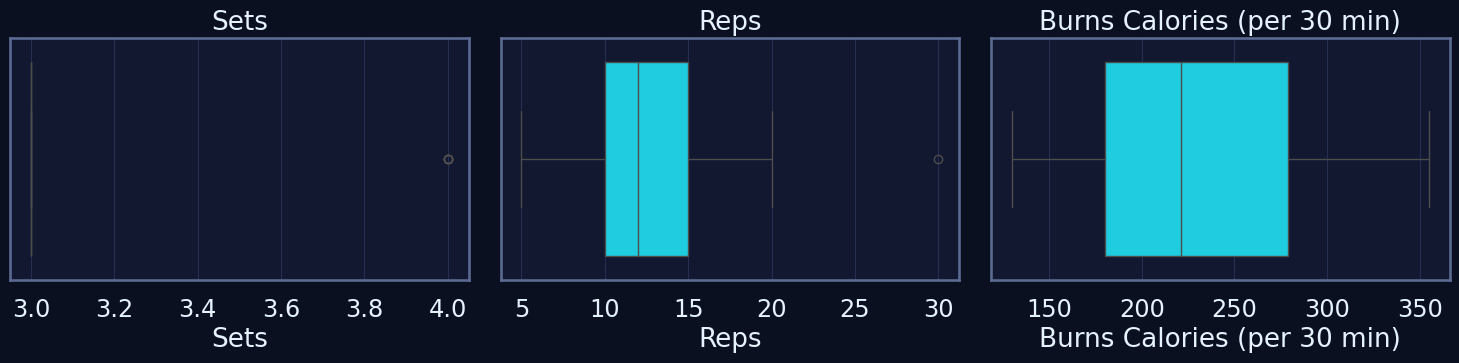

In [68]:
plt.figure(figsize=(5 * len(num_cols), 4))

for i, col in enumerate(num_cols, start=1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.grid(True, axis="x")

plt.tight_layout()
plt.show()


### Z-Score complémentaire (|Z| > 3)


In [69]:
df_num = df[num_cols].apply(pd.to_numeric, errors="coerce")

z_scores = np.abs(stats.zscore(df_num, nan_policy="omit"))
z_scores = pd.DataFrame(z_scores, columns=num_cols)

outlier_z = (z_scores > 3).sum()
outlier_z_df = pd.DataFrame({
    "Variable": num_cols,
    "Outliers_Z>3": outlier_z.values
})

display(outlier_z_df)


,Variable,Outliers_Z>3
0,Sets,0
1,Reps,1
2,Burns Calories (per 30 min),0


### Modalités rares (catégorielles) — détection simple


In [70]:
rare_modalities = {}

for col in cat_cols:
    vc = df[col].value_counts()
    rare = vc[vc == 1]  # seuil = 1 occurrence
    rare_modalities[col] = rare

print("\nModalités rares détectées :")
for col, rare in rare_modalities.items():
    print(f"\n{col} :")
    display(rare)



Modalités rares détectées :

Benefit :


Benefit
Builds lower body power                            1
Isolates triceps                                   1
Improves back strength and posture                 1
Targets lower abs                                  1
Builds back strength                               1
Improves unilateral leg strength and balance       1
Improves posture and strengthens upper back        1
Improves shoulder mobility and posture             1
Improves core stability and balance                1
Builds explosive upper body power                  1
Targets upper chest                                1
Targets lower chest                                1
Improves core stability                            1
Builds unilateral leg strength and balance         1
Targets biceps and forearms                        1
Advanced core exercise                             1
Improves core stability and upper body strength    1
Builds lower body power and endurance              1
Enhances full-body coordination and st


Target Muscle Group :


Target Muscle Group
Lower Chest, Triceps          1
Shoulders, Upper Back         1
Upper Chest, Triceps          1
Full Core                     1
Biceps, Forearms              1
Quadriceps, Glutes            1
Back, Core, Shoulders         1
Quadriceps, Calves, Glutes    1
Full Body, Core, Shoulders    1
Core, Shoulders, Hips         1
Obliques, Core                1
Lower Abs, Hip Flexors        1
Legs, Core                    1
Rear Deltoids, Upper Back     1
Glutes, Hamstrings, Core      1
Lower Back, Glutes            1
Glutes, Hamstrings            1
Shoulders                     1
Calves                        1
Shoulders, Triceps            1
Chest, Triceps                1
Back, Hamstrings, Glutes      1
Core, Obliques                1
Triceps, Chest                1
Core                          1
Core, Shoulders, Legs         1
Legs, Shoulders, Core         1
Name: count, dtype: int64


Equipment Needed :


Equipment Needed
Parallel Bars or Chair              1
Bench or Chair                      1
Wall                                1
Resistance Band                     1
Low Bar or TRX                      1
Cable Machine or Resistance Band    1
Step or Box                         1
Cable Machine                       1
Resistance Band or Cable Machine    1
Box or Platform                     1
Bench, Barbell                      1
Barbell                             1
None or Dumbbell                    1
Bench or Sturdy Surface             1
Name: count, dtype: int64


Difficulty Level :


Series([], Name: count, dtype: int64)

### Observations atypiques via l’espace ACM (MCA)


Top 15 exercices les plus atypiques dans l'espace MCA :


,Name of Exercise,Equipment Needed,Target Muscle Group,Benefit,Difficulty Level,mca_distance
20,Box Jumps,Box or Platform,"Legs, Core",Builds explosive power,Advanced,3.131438
35,Wall Angels,Wall,"Shoulders, Upper Back",Improves shoulder mobility and posture,Beginner,2.832780
11,Deadlifts,Barbell,"Back, Hamstrings, Glutes",Strengthens back and legs,Advanced,2.395658
43,Dragon Flags,Bench or Sturdy Surface,Full Core,Advanced core exercise,Advanced,2.308076
7,Dips,Parallel Bars or Chair,"Triceps, Chest",Strengthens triceps and chest,Intermediate,1.931000
46,Turkish Get-ups,Kettlebell,"Full Body, Core, Shoulders",Enhances full-body coordination and stability,Advanced,1.767274
12,Bench Press,"Bench, Barbell","Chest, Triceps",Builds chest strength,Intermediate,1.743080
48,Windshield Wipers,Pull-up Bar,"Obliques, Core",Targets obliques and improves core rotation,Advanced,1.739603
34,Resistance Band Pull-Aparts,Resistance Band,"Upper Back, Rear Deltoids",Improves shoulder health and posture,Beginner,1.577949
23,Face Pulls,Resistance Band or Cable Machine,"Rear Deltoids, Upper Back",Improves shoulder health and posture,Intermediate,1.520091


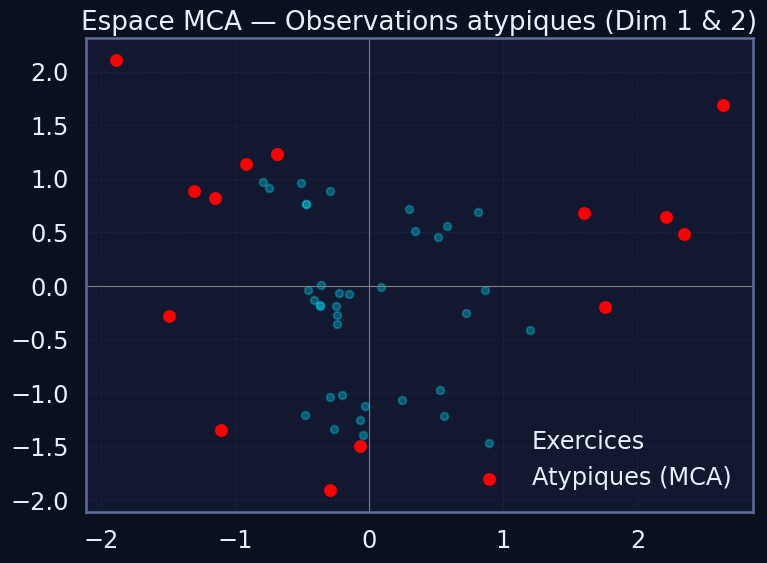

In [72]:
# Vérification rapide
assert "mca" in globals(), "L'objet 'mca' doit être défini dans la section MCA."
assert "df_cat" in globals(), "Le DataFrame 'df_cat' doit être défini dans la section MCA."

# Coordonnées des individus dans l'espace factoriel
coords = mca.transform(df_cat)

# Si coords n'est pas un DataFrame, on le convertit
if not isinstance(coords, pd.DataFrame):
    coords = pd.DataFrame(coords, index=df_cat.index)

# Distance euclidienne à l'origine (axes principaux)
dist = np.sqrt((coords**2).sum(axis=1))
dist.name = "mca_distance"

# On ajoute la distance au DataFrame original pour inspection
df_mca_outliers = df.copy()
df_mca_outliers["mca_distance"] = dist

# Top exercices les plus éloignés
top_k = 15
mca_outliers = df_mca_outliers.sort_values("mca_distance", ascending=False).head(top_k)

print(f"Top {top_k} exercices les plus atypiques dans l'espace MCA :")
cols_to_show = [
    "Name of Exercise",
    "Equipment Needed",
    "Target Muscle Group",
    "Benefit",
    "Difficulty Level",
    "mca_distance",
]
cols_to_show = [c for c in cols_to_show if c in mca_outliers.columns]
display(mca_outliers[cols_to_show])

# Visualisation simple (Dim 1 & 2) avec mise en évidence des points extrêmes
coords_2d = coords.iloc[:, :2].copy()
coords_2d.columns = ["Dim1", "Dim2"]

plt.figure(figsize=(8, 6))
plt.scatter(coords_2d["Dim1"], coords_2d["Dim2"], s=30, alpha=0.3, label="Exercices")
plt.scatter(
    coords_2d.loc[mca_outliers.index, "Dim1"],
    coords_2d.loc[mca_outliers.index, "Dim2"],
    s=60,
    color="red",
    label="Atypiques (MCA)",
)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title("Espace MCA — Observations atypiques (Dim 1 & 2)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
